In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import bbknn
import os
from scipy import sparse
import wget
import scgen
from scgen.file_utils import ensure_dir_for_file
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80)  # low dpi (dots per inch) yields small inline figures
sc.logging.print_versions()

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-17 02:44:13.942102: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 02:44:14.042932: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


Package,Version
wget,3.2
Component,Info
Python,"3.10.19 | packaged by conda-forge | (main, Jan 26 2026, 23:45:08) [GCC 14.3.0]"
OS,Linux-6.1.159-181.297.amzn2023.x86_64-x86_64-with-glibc2.35
CPU,"16 logical CPU cores, x86_64"
GPU,"ID: 0, NVIDIA L40S, Driver: 580.126.09, Memory: 46068 MiB"
Updated,2026-02-17 02:44
Dependency,Version
pynndescent,0.6.0
adjustText,1.3.0


In [2]:
train_path = "../data/pancreas.h5ad"
if os.path.isfile(train_path):
    adata = scgen.load_file(train_path)
else:
    os.makedirs(os.path.dirname(train_path), exist_ok=True)
    train_url = "https://www.dropbox.com/s/zvmt8oxhfksumw2/pancreas.h5ad?dl=1"
    t_dl = wget.download(train_url, train_path)
    adata = scgen.load_file(train_path)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


computing PCA
    with n_comps=50
    finished (0:00:01)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:28)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 9 clusters and added
    'louvain', the cluster labels (adata.obs, categorical) (0:00:00)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

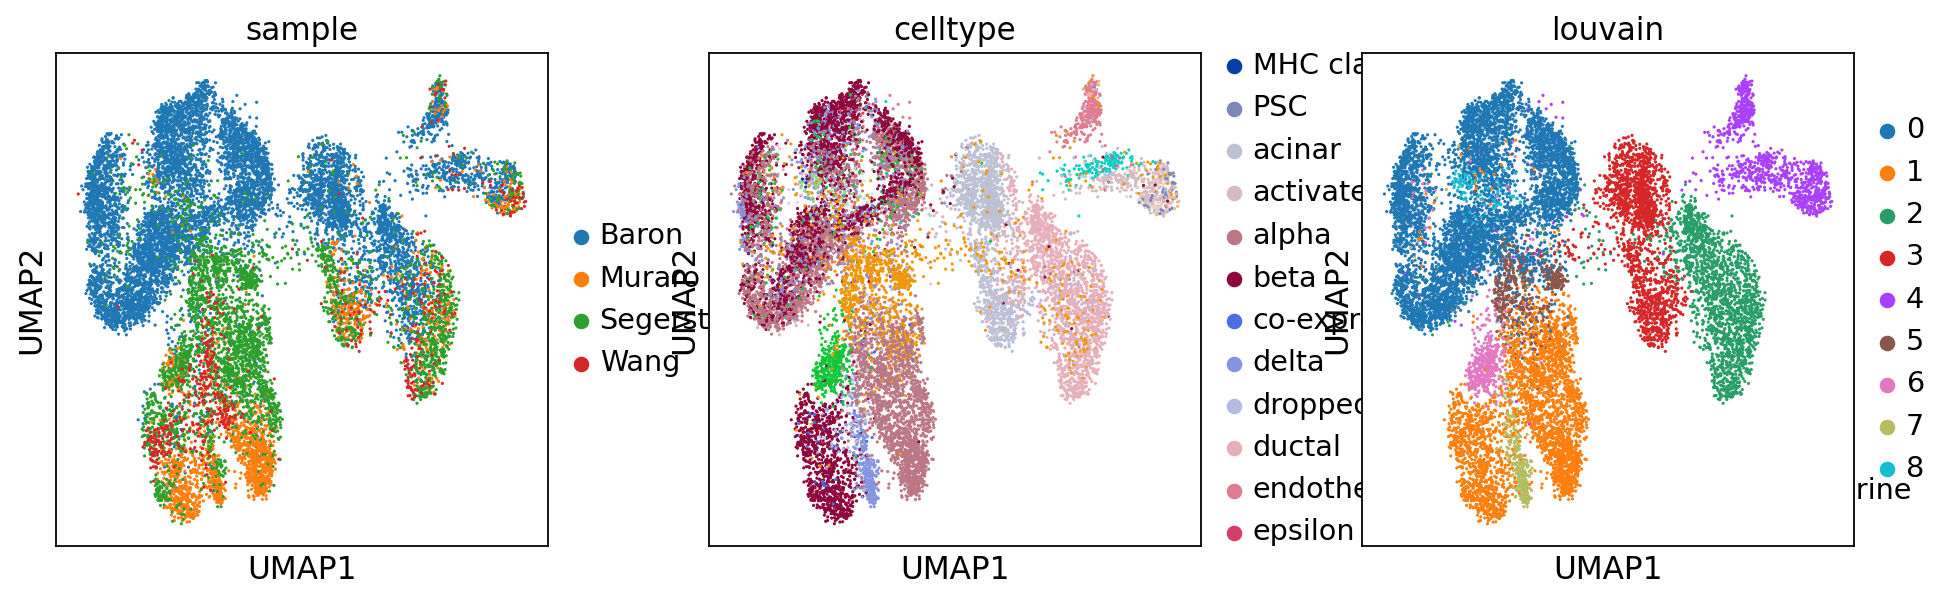

In [3]:
sc.tl.pca(adata, svd_solver='arpack')
adata.obsm['X_pca'] *= -1  # multiply by -1 to match Seurat
adata_bbknn = bbknn.bbknn(adata, copy=True,neighbors_within_batch=5,trim=50)
sc.tl.umap(adata_bbknn)
sc.tl.louvain(adata_bbknn)
sc.pl.umap(adata_bbknn, color=['sample','celltype',"louvain"])

In [4]:
adata_bbknn.write(ensure_dir_for_file("../data/bbknn.h5ad"))